# Reentrenamiento HMM - ETTh2 K=5
Entrena Baum-Welch sobre datos RevIN-normalizados (per-window) y genera visualizaciones de las 4 fases.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

from hmm.baum_welch import baum_welch
from hmm.viterbi import viterbi_decode
from embeddings import EmbeddingGenerator

plt.style.use('seaborn-v0_8-paper')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

colors_oi = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

print(f'Working directory: {Path.cwd()}')

Working directory: /home/jaime/TFG/RITMO


## 1. Carga ETTh2 + RevIN

[ETTh2] Total: 17420, Train: 12194
  Range: [0.000, 58.877]
  Mean: 28.817, Std: 11.403
  Ventanas: 127 x 96 = 12192 timesteps
  RevIN-normalized: mean=0.000000, std=1.000000


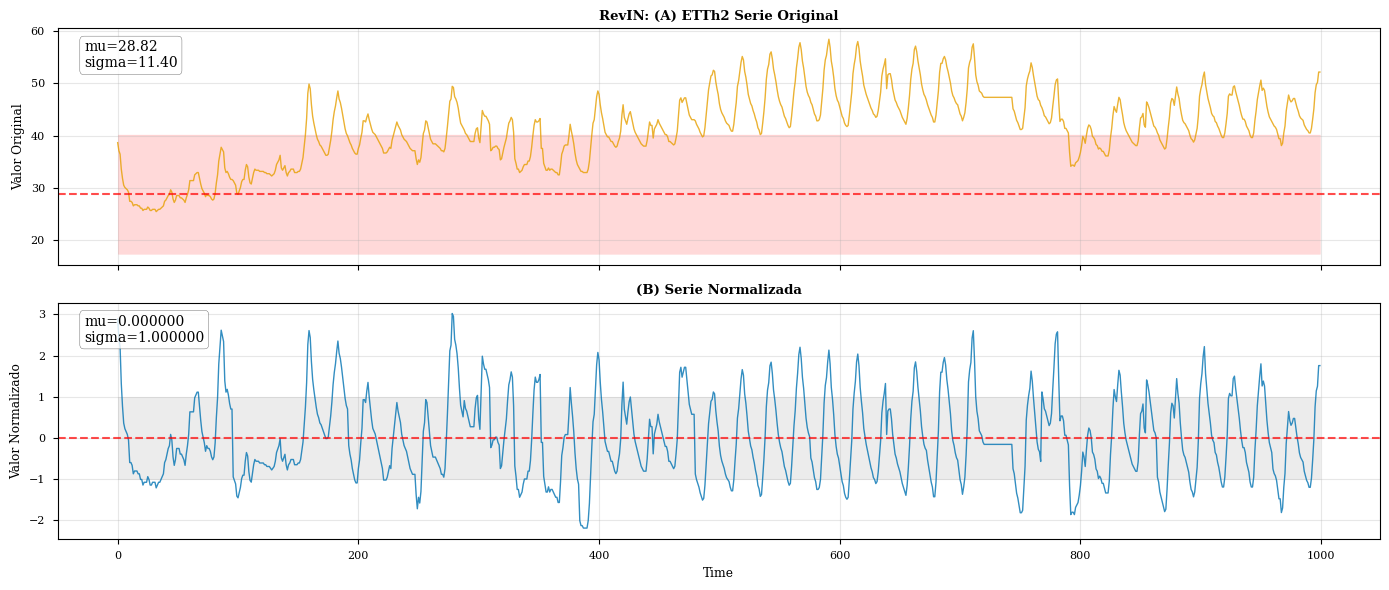

In [2]:
df = pd.read_csv('dataset/ETT-small/ETTh2.csv')
data = df['OT'].values
n_train = int(len(df) * 0.7)
train_ot = data[:n_train]

print(f'[ETTh2] Total: {len(data)}, Train: {len(train_ot)}')
print(f'  Range: [{train_ot.min():.3f}, {train_ot.max():.3f}]')
print(f'  Mean: {train_ot.mean():.3f}, Std: {train_ot.std():.3f}')

# RevIN per-window (identico al pipeline)
seq_len = 96
windows = []
for start in range(0, len(train_ot) - seq_len + 1, seq_len):
    window = train_ot[start:start + seq_len]
    w_mean, w_std = window.mean(), max(window.std(), 1e-5)
    windows.append((window - w_mean) / w_std)

train_norm = np.concatenate(windows)
print(f'  Ventanas: {len(windows)} x {seq_len} = {len(train_norm)} timesteps')
print(f'  RevIN-normalized: mean={train_norm.mean():.6f}, std={train_norm.std():.6f}')

# Fase 1 viz: antes/despues
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
t_viz = 1000

ax1.plot(train_ot[:t_viz], color=colors_oi[0], linewidth=1, alpha=0.8)
ax1.axhline(train_ot.mean(), color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.fill_between(range(t_viz), train_ot.mean()-train_ot.std(), train_ot.mean()+train_ot.std(), alpha=0.15, color='red')
ax1.text(0.02, 0.95, f'mu={train_ot.mean():.2f}\nsigma={train_ot.std():.2f}', transform=ax1.transAxes, fontsize=10, va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax1.set_ylabel('Valor Original')
ax1.set_title('RevIN: (A) ETTh2 Serie Original', fontweight='bold')
ax1.grid(alpha=0.3)

ax2.plot(train_norm[:t_viz], color=colors_oi[4], linewidth=1, alpha=0.8)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.fill_between(range(t_viz), -1, 1, alpha=0.15, color='gray')
ax2.text(0.02, 0.95, f'mu={train_norm.mean():.6f}\nsigma={train_norm.std():.6f}', transform=ax2.transAxes, fontsize=10, va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.set_ylabel('Valor Normalizado')
ax2.set_xlabel('Time')
ax2.set_title('(B) Serie Normalizada', fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/fase1_revin_etth2.png', dpi=300)
plt.show()

## 2. Baum-Welch Training

In [3]:
K = 5
cache_path = Path('cache/hmm_etth2_K5.pth')
cache_path.parent.mkdir(exist_ok=True)

print(f'[BAUM-WELCH] K={K}, T={len(train_norm)}')

result = baum_welch(
    observations=train_norm,
    K=K,
    max_iter=500,
    epsilon=1e-4,
    random_state=42,
    verbose=True
)

A, pi, mu, sigma = result['A'], result['pi'], result['mu'], result['sigma']
log_likelihoods = result.get('log_likelihoods', [])

print(f'\nconverged: {result["converged"]}')
print(f'n_iter: {result["n_iter"]}')
print(f'log_likelihood: {result["log_likelihood"]:.4f}')
print(f'mu: {mu}')
print(f'sigma: {sigma}')
print(f'A diagonal: {np.diag(A)}')

assert result['converged'], f'NO CONVERGIO en {result["n_iter"]} iters'
assert np.all(sigma > 0), 'sigma tiene valores <= 0'
assert np.allclose(A.sum(axis=1), 1.0, atol=1e-6), 'Filas de A no suman 1'
print('Validaciones OK')

[BAUM-WELCH] K=5, T=12192


Baum-Welch EM:  46%|████▌     | 230/500 [40:16<47:17, 10.51s/it, LL=-6804.52, ΔLL=9.65e-05]  


Convergió en iteración 231/500
  Log-likelihood final: -6804.5241

converged: True
n_iter: 231
log_likelihood: -6804.5241
mu: [-0.6209477   0.62043522 -0.0715721   1.61432406 -1.23596137]
sigma: [0.17692941 0.2690333  0.19745292 0.47711002 0.32138951]
A diagonal: [0.76622029 0.68905957 0.70717566 0.83806144 0.88035571]
Validaciones OK


In [4]:
# Guardar cache
cache = {
    'A': torch.from_numpy(A).float(),
    'pi': torch.from_numpy(pi).float(),
    'mu': torch.from_numpy(mu).float(),
    'sigma': torch.from_numpy(sigma).float(),
    'log_likelihood': result['log_likelihood'],
    'converged': result['converged'],
    'n_iter': result['n_iter'],
}
torch.save(cache, str(cache_path))
print(f'Cache guardado en {cache_path}')

# Verificar
check = torch.load(str(cache_path), weights_only=False)
assert check['converged']
print('Cache verificado OK')

Cache guardado en cache/hmm_etth2_K5.pth
Cache verificado OK


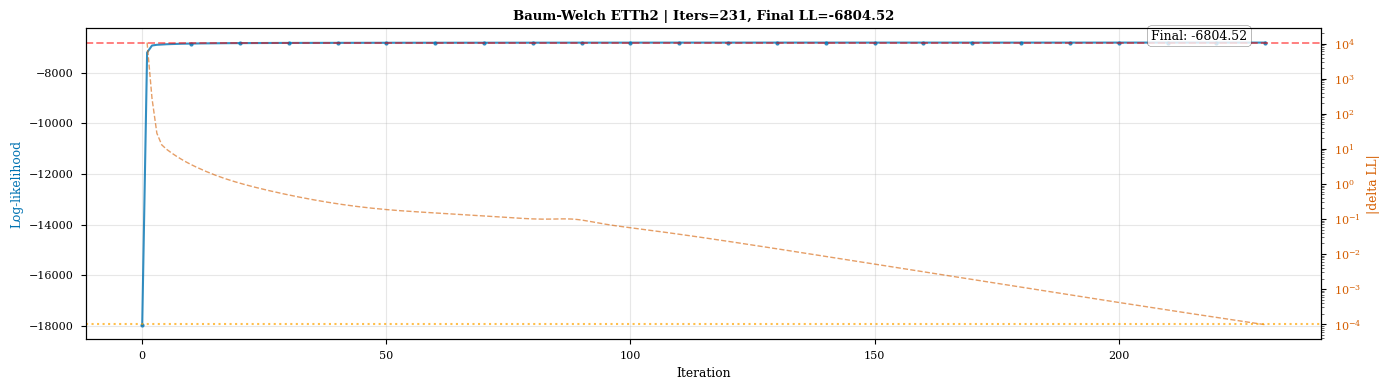

In [5]:
# Fase 2 viz: convergencia
if len(log_likelihoods) > 1:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(log_likelihoods, color=colors_oi[4], linewidth=1.5, marker='o', markersize=3, markevery=10, alpha=0.8)
    ax.axhline(log_likelihoods[-1], color='red', linestyle='--', alpha=0.5)
    ax.text(len(log_likelihoods)*0.98, log_likelihoods[-1], f'Final: {log_likelihoods[-1]:.2f}', ha='right', va='bottom', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax2 = ax.twinx()
    deltas = np.abs(np.diff(log_likelihoods))
    ax2.plot(range(1, len(deltas)+1), deltas, color=colors_oi[5], linewidth=1, alpha=0.6, linestyle='--')
    ax2.axhline(1e-4, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
    ax2.set_ylabel('|delta LL|', color=colors_oi[5])
    ax2.set_yscale('log')
    ax2.tick_params(axis='y', labelcolor=colors_oi[5])

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log-likelihood', color=colors_oi[4])
    ax.set_title(f'Baum-Welch ETTh2 | Iters={len(log_likelihoods)}, Final LL={log_likelihoods[-1]:.2f}', fontweight='bold')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('notebooks/fase2_baum_welch_etth2.png', dpi=300)
    plt.show()

## 3. Viterbi Tokenizacion

[VITERBI] K=5, T=12192
  Segmentos: 2650, CR=4.60x
  Token 0: 2624 (21.5%)
  Token 1: 2406 (19.7%)
  Token 2: 2698 (22.1%)
  Token 3: 2044 (16.8%)
  Token 4: 2420 (19.8%)


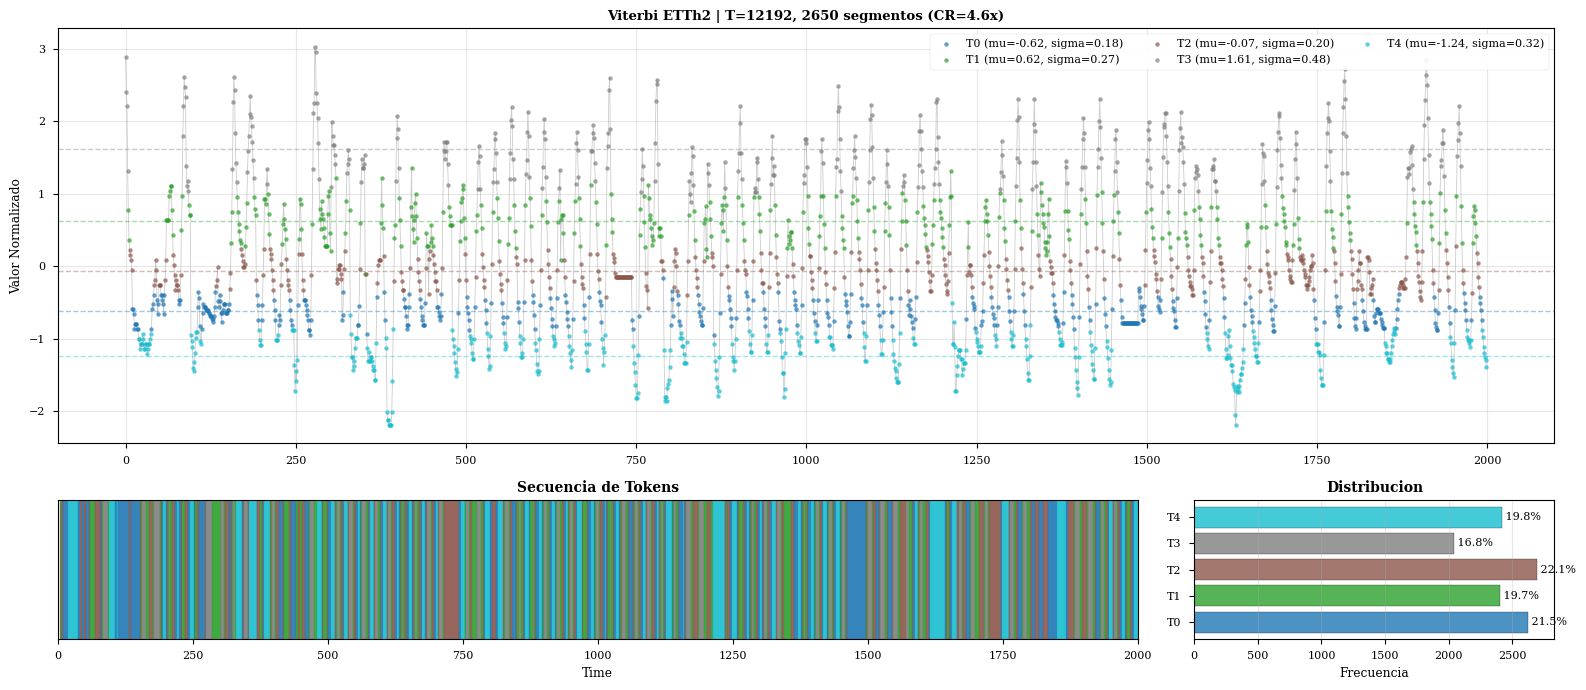

In [6]:
states, log_prob = viterbi_decode(train_norm, A, pi, mu, sigma)

state_changes = np.sum(states[1:] != states[:-1])
compression_ratio = len(train_norm) / (state_changes + 1)

print(f'[VITERBI] K={K}, T={len(states)}')
print(f'  Segmentos: {state_changes+1}, CR={compression_ratio:.2f}x')
for k in range(K):
    count = np.sum(states == k)
    print(f'  Token {k}: {count:4d} ({100*count/len(states):.1f}%)')

# Fase 3 viz: serie coloreada + barra tokens + distribucion
fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[3, 1], width_ratios=[3, 1])
ax_series = fig.add_subplot(gs[0, :])
ax_bar = fig.add_subplot(gs[1, 0])
ax_stats = fig.add_subplot(gs[1, 1])

t_viz = 2000
colors_tokens = plt.cm.tab10(np.linspace(0, 1, K))

ax_series.plot(train_norm[:t_viz], color='gray', linewidth=0.6, alpha=0.4, zorder=1)
for k in range(K):
    mask = states[:t_viz] == k
    if np.any(mask):
        ax_series.scatter(np.where(mask)[0], train_norm[:t_viz][mask], color=colors_tokens[k], s=8, alpha=0.7, label=f'T{k} (mu={mu[k]:.2f}, sigma={sigma[k]:.2f})', zorder=2)
        ax_series.axhline(mu[k], color=colors_tokens[k], linestyle='--', linewidth=1, alpha=0.4)

ax_series.set_ylabel('Valor Normalizado')
ax_series.set_title(f'Viterbi ETTh2 | T={len(states)}, {state_changes+1} segmentos (CR={compression_ratio:.1f}x)', fontweight='bold')
ax_series.legend(loc='upper right', fontsize=8, ncol=3, framealpha=0.9)
ax_series.grid(alpha=0.3)

segment_starts = np.where(np.diff(np.concatenate([[states[0]], states[:t_viz]])) != 0)[0]
segment_starts = np.concatenate([segment_starts, [t_viz]])
for i in range(len(segment_starts)-1):
    start = segment_starts[i]
    end = segment_starts[i+1]
    ax_bar.axvspan(start, end, color=colors_tokens[states[start]], alpha=0.9)

ax_bar.set_xlim(0, t_viz)
ax_bar.set_yticks([])
ax_bar.set_xlabel('Time')
ax_bar.set_title('Secuencia de Tokens', fontweight='bold', fontsize=10)

token_counts = [np.sum(states == k) for k in range(K)]
ax_stats.barh(range(K), token_counts, color=colors_tokens, alpha=0.8, edgecolor='black')
ax_stats.set_yticks(range(K))
ax_stats.set_yticklabels([f'T{k}' for k in range(K)])
ax_stats.set_xlabel('Frecuencia')
ax_stats.set_title('Distribucion', fontweight='bold', fontsize=10)
ax_stats.grid(alpha=0.3, axis='x')
for k in range(K):
    pct = 100 * token_counts[k] / len(states)
    ax_stats.text(token_counts[k], k, f' {pct:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/fase3_viterbi_etth2.png', dpi=300)
plt.show()

## 4. Embeddings Estructurados

[EMBEDDINGS] e_k = [mu_k, sigma_k, A[k,:]]
  K=5, dim_cruda=7, d_model=128


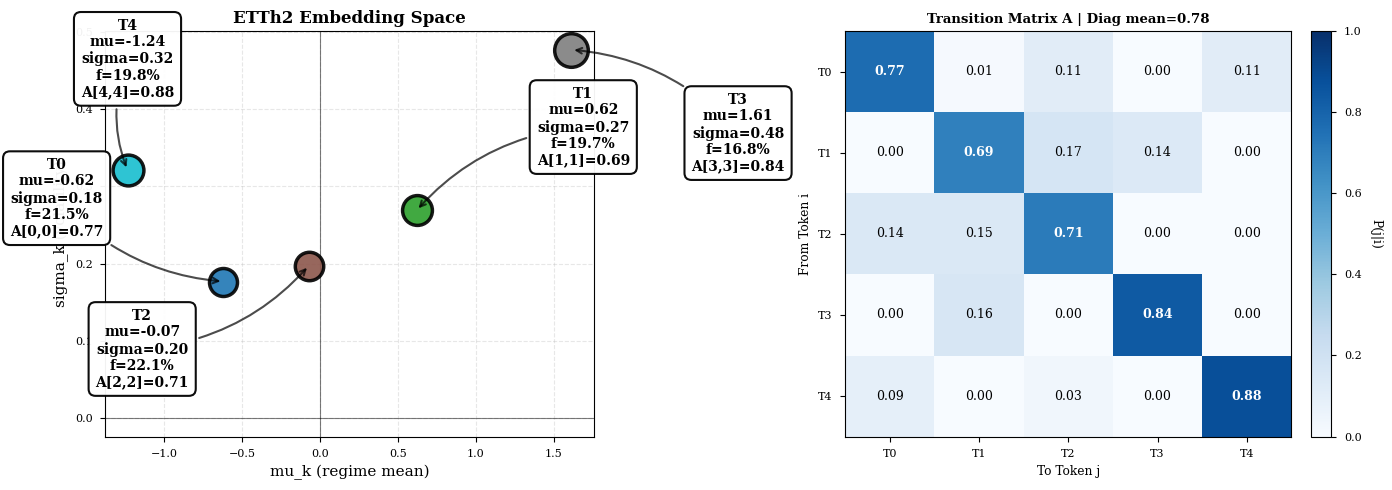

Todas las figuras guardadas en notebooks/


In [7]:
hmm_params_dict = {'A': A, 'mu': mu, 'sigma': sigma, 'pi': pi}
emb_gen = EmbeddingGenerator(hmm_params_dict, d_model=128, device='cpu')
embedding_table = emb_gen.get_embedding_table().numpy()

print(f'[EMBEDDINGS] e_k = [mu_k, sigma_k, A[k,:]]')
print(f'  K={K}, dim_cruda={embedding_table.shape[1]}, d_model={emb_gen.d_model}')

# Fase 4 viz: espacio mu-sigma + matriz A
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

offsets = [(-120, 60), (120, 60), (-120, -60), (120, -60), (0, 80)]
for k in range(K):
    size = 300 + sigma[k] * 600
    ax1.scatter(mu[k], sigma[k], c=[colors_tokens[k]], s=size, edgecolors='black', linewidths=2.5, zorder=3, alpha=0.9)
    freq_pct = 100 * np.sum(states == k) / len(states)
    ax1.annotate(f'T{k}\nmu={mu[k]:.2f}\nsigma={sigma[k]:.2f}\nf={freq_pct:.1f}%\nA[{k},{k}]={A[k,k]:.2f}',
                xy=(mu[k], sigma[k]), xytext=offsets[k], textcoords='offset points',
                fontsize=10, ha='center', va='center', fontweight='bold', zorder=5,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.95, linewidth=1.5),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', color='black', lw=1.5, alpha=0.7))

ax1.set_xlabel('mu_k (regime mean)', fontsize=11)
ax1.set_ylabel('sigma_k (volatility)', fontsize=11)
ax1.set_title('ETTh2 Embedding Space', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3, linestyle='--')
ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax1.axvline(0, color='black', linewidth=0.8, alpha=0.5)

im = ax2.imshow(A, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax2.set_xlabel('To Token j')
ax2.set_ylabel('From Token i')
ax2.set_title(f'Transition Matrix A | Diag mean={np.diag(A).mean():.2f}', fontweight='bold')
ax2.set_xticks(range(K))
ax2.set_yticks(range(K))
ax2.set_xticklabels([f'T{k}' for k in range(K)])
ax2.set_yticklabels([f'T{k}' for k in range(K)])
for i in range(K):
    for j in range(K):
        ax2.text(j, i, f'{A[i,j]:.2f}', ha='center', va='center', color='white' if A[i,j] > 0.5 else 'black', fontsize=9, fontweight='bold' if i==j else 'normal')

cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('P(j|i)', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('notebooks/fase4_embeddings_etth2.png', dpi=300)
plt.show()
print('Todas las figuras guardadas en notebooks/')